# Sleep Health & Lifestyle — Predictive Analysis
**CA6000 Applied AI Programming**

---

## Project Overview

This notebook investigates the **Sleep Health and Lifestyle Dataset** from Kaggle, tackling **two complementary prediction tasks**:

| Task | Type | Target |
|------|------|--------|
| Task A | Regression | Predict **Quality of Sleep** (score 1–10) |
| Task B | Classification | Predict **Sleep Disorder** (None / Insomnia / Sleep Apnea) |

**Pipeline:**
1. Load & inspect data
2. Statistical summary
3. Data dirtying → cleaning
4. Exploratory Data Analysis (EDA)
5. Feature engineering & preprocessing
6. Task A — Regression: Linear Regression vs Neural Network vs XGBoost
7. Task B — Classification: Logistic Regression vs Neural Network vs XGBoost
8. Cross-validation & final evaluation
9. Conclusion

---
## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# XGBoost
import xgboost as xgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print('All libraries loaded.')
print(f'TensorFlow: {tf.__version__}')
print(f'XGBoost:    {xgb.__version__}')

All libraries loaded.
TensorFlow: 2.19.1
XGBoost:    3.2.0


---
## Cell 2 — Load Dataset

In [2]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print('\n--- Note on Sleep Disorder NaN ---')
print("NaN in 'Sleep Disorder' does NOT mean missing data.")
print("It means the person has NO sleep disorder — needs special handling.")
df.head(10)

Dataset shape: (374, 13)

Columns: ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

Data types:
Person ID                    int64
Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Blood Pressure                 str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str
dtype: object

Missing values:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Categor

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


---
## Cell 3 — Statistical Summary

In [3]:
print('=' * 60)
print('DESCRIPTIVE STATISTICS (Numerical Columns)')
print('=' * 60)
print(df.describe().round(2).to_string())

print('\n' + '=' * 60)
print('SKEWNESS — measures distribution asymmetry')
print('(|skew| > 1 = highly skewed, informs imputation choice)')
print('=' * 60)
print(df.skew(numeric_only=True).round(3).to_string())

print('\n' + '=' * 60)
print('CATEGORICAL COLUMN DISTRIBUTIONS')
print('=' * 60)
for col in df.select_dtypes(include='object').columns:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())

DESCRIPTIVE STATISTICS (Numerical Columns)
       Person ID     Age  Sleep Duration  Quality of Sleep  Physical Activity Level  Stress Level  Heart Rate  Daily Steps
count     374.00  374.00          374.00            374.00                   374.00        374.00      374.00       374.00
mean      187.50   42.18            7.13              7.31                    59.17          5.39       70.17      6816.84
std       108.11    8.67            0.80              1.20                    20.83          1.77        4.14      1617.92
min         1.00   27.00            5.80              4.00                    30.00          3.00       65.00      3000.00
25%        94.25   35.25            6.40              6.00                    45.00          4.00       68.00      5600.00
50%       187.50   43.00            7.20              7.00                    60.00          5.00       70.00      7000.00
75%       280.75   50.00            7.80              8.00                    75.00          7.0

---
## Cell 4 — Fix Sleep Disorder NaN (Special Case)

**Important insight:** The `Sleep Disorder` column uses `NaN` to represent *no disorder*, not a missing value.
This must be fixed **before** any dirtying phase — otherwise we cannot distinguish real missing values
from this intentional encoding.

In [4]:
# Replace NaN with string 'None' — this is meaningful data, not missing
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

print('Sleep Disorder distribution after fix:')
print(df['Sleep Disorder'].value_counts())
print(f"\nRemaining NaN in Sleep Disorder: {df['Sleep Disorder'].isnull().sum()}")

# Drop Person ID — not a predictive feature
if 'Person ID' in df.columns:
    df.drop(columns=['Person ID'], inplace=True)
    print("\nDropped 'Person ID' column.")

Sleep Disorder distribution after fix:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

Remaining NaN in Sleep Disorder: 0

Dropped 'Person ID' column.


---
## Cell 5 — Data Dirtying Phase

We intentionally inject two types of errors to simulate real-world data quality problems:

| Error type | Column | Simulation rationale |
|------------|--------|----------------------|
| Missing values (~5%) | `Sleep Duration` | People **with a sleep disorder** are more likely to skip filling in sleep duration — this is a realistic, non-random pattern (MAR) |
| Realistic outliers | `Age` | Values in range 150–200, simulating a date-of-birth entry error (e.g. year typed instead of age) |
| Realistic outliers | `Daily Steps` | Values in range 50,000–80,000, simulating a faulty fitness tracker reading |

Using plausible (not obviously fake) outlier values makes the stress-test more representative of real production data issues.

Missing values injected in 'Sleep Duration': 18
  (sampled from 155 rows with a sleep disorder)
Outliers injected in 'Age':        5 rows, values [185 167 198 188 181]
Outliers injected in 'Daily Steps':5 rows, values [76263 73190 57357 78708 62043]


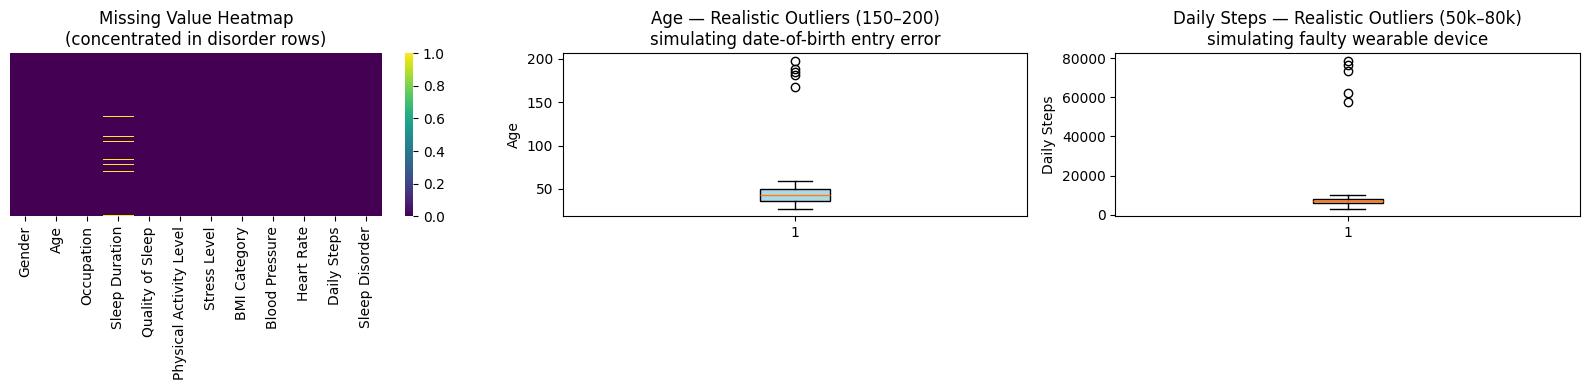

In [5]:
np.random.seed(42)
df_dirty = df.copy()

# --- Inject 1: Missing values in Sleep Duration ---
# People with a sleep disorder are more likely to skip this field.
# This creates a non-random (MAR) missing pattern, more realistic than
# purely random deletion.
disorder_idx = df_dirty[df_dirty['Sleep Disorder'] != 'None'].index
n_missing = int(0.05 * len(df_dirty))
n_missing = min(n_missing, len(disorder_idx))  # Can't sample more than available
missing_idx = np.random.choice(disorder_idx, size=n_missing, replace=False)
df_dirty.loc[missing_idx, 'Sleep Duration'] = np.nan

# --- Inject 2: Realistic outliers in Age ---
# Simulates a date-of-birth data-entry error (e.g. birth year recorded
# instead of age). Values 150–200 are physiologically impossible
# but not as obviously fake as 999.
outlier_idx = np.random.choice(df_dirty.index, size=5, replace=False)
df_dirty.loc[outlier_idx, 'Age'] = np.random.randint(150, 201, size=5)

# --- Inject 3: Realistic outliers in Daily Steps ---
# Simulates a faulty wearable device recording implausibly high step counts.
# 50,000–80,000 steps/day is beyond human capacity but not an obvious
# placeholder value like 99999.
df_dirty.loc[outlier_idx, 'Daily Steps'] = np.random.randint(50000, 80001, size=5)

print(f"Missing values injected in 'Sleep Duration': {df_dirty['Sleep Duration'].isnull().sum()}")
print(f"  (sampled from {len(disorder_idx)} rows with a sleep disorder)")
print(f"Outliers injected in 'Age':        {5} rows, values {df_dirty.loc[outlier_idx, 'Age'].values}")
print(f"Outliers injected in 'Daily Steps':{5} rows, values {df_dirty.loc[outlier_idx, 'Daily Steps'].values}")

# Visualise the injected problems
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Missing value heatmap
sns.heatmap(df_dirty.isnull(), cbar=True, yticklabels=False,
            ax=axes[0], cmap='viridis')
axes[0].set_title('Missing Value Heatmap\n(concentrated in disorder rows)')

# Age boxplot — outliers visible but not absurdly high
axes[1].boxplot(df_dirty['Age'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Age — Realistic Outliers (150–200)\nsimulating date-of-birth entry error')
axes[1].set_ylabel('Age')

# Daily Steps boxplot
axes[2].boxplot(df_dirty['Daily Steps'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightsalmon'))
axes[2].set_title('Daily Steps — Realistic Outliers (50k–80k)\nsimulating faulty wearable device')
axes[2].set_ylabel('Daily Steps')

plt.tight_layout()
plt.show()

---
## Cell 6 — Data Cleaning Phase

| Problem | Solution | Rationale |
|---------|----------|-----------|
| Missing `Sleep Duration` | **Median imputation** | Median is robust to skew; mean would be pulled by extreme values |
| Outliers in `Age` / `Daily Steps` | **IQR method** | Data-driven threshold — more scientific than hardcoded limits |
| `Blood Pressure` stored as string | **Split into Systolic + Diastolic** | Two numeric features are more useful for models |

Sleep Duration NaN filled with median: 7.2

Outlier removal (IQR method):
  'Age': removed 5 row(s)  |  bounds [15.0, 71.0]
  'Daily Steps': removed 0 row(s)  |  bounds [3000.0, 11000.0]

Blood Pressure split into Systolic and Diastolic.

Dataset shape after cleaning: (369, 13)
Remaining missing values: 0


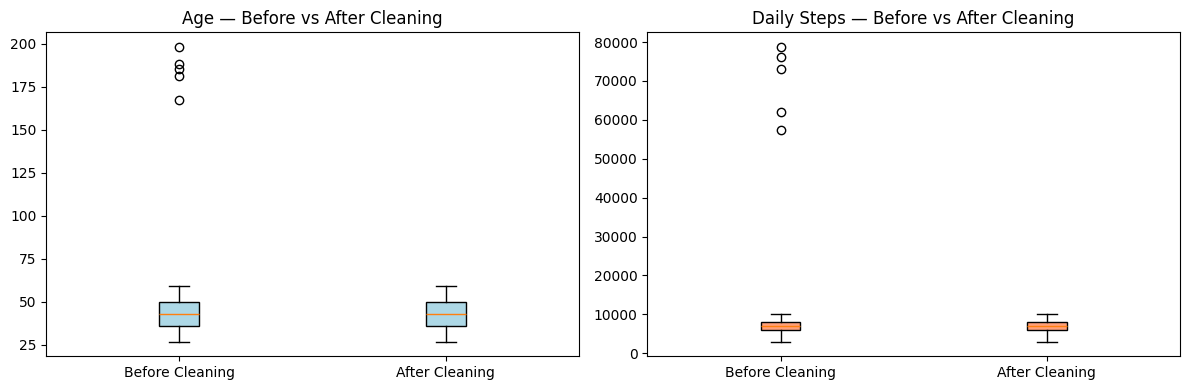


Note: IQR filtering is used here to handle the injected outliers.
In a real scenario it may also remove some naturally extreme but valid observations.


In [6]:
df_clean = df_dirty.copy()

# Fix 1: Median imputation for Sleep Duration
# Median chosen over mean because skewed distributions make the mean unreliable
median_sleep = df_clean['Sleep Duration'].median()
df_clean.fillna({'Sleep Duration': median_sleep}, inplace=True)
print(f'Sleep Duration NaN filled with median: {median_sleep}')

# Fix 2: IQR-based outlier removal (data-driven, not hardcoded)
def remove_outliers_iqr(dataframe, col):
    Q1  = dataframe[col].quantile(0.25)
    Q3  = dataframe[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    before = len(dataframe)
    df_out = dataframe[dataframe[col].between(lo, hi)]
    print(f"  '{col}': removed {before - len(df_out)} row(s)  |  bounds [{lo:.1f}, {hi:.1f}]")
    return df_out

print('\nOutlier removal (IQR method):')
df_clean = remove_outliers_iqr(df_clean, 'Age')
df_clean = remove_outliers_iqr(df_clean, 'Daily Steps')

# Fix 3: Split Blood Pressure string '120/80' → two numeric columns
df_clean[['Systolic', 'Diastolic']] = (
    df_clean['Blood Pressure'].str.split('/', expand=True).astype(float)
)
df_clean.drop(columns=['Blood Pressure'], inplace=True)
print('\nBlood Pressure split into Systolic and Diastolic.')

print(f'\nDataset shape after cleaning: {df_clean.shape}')
print(f'Remaining missing values: {df_clean.isnull().sum().sum()}')

# Before vs after boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes,
                           ['Age', 'Daily Steps'],
                           ['lightblue', 'lightsalmon']):
    ax.boxplot(
        [df_dirty[col].dropna(), df_clean[col].dropna()],
        labels=['Before Cleaning', 'After Cleaning'],
        patch_artist=True,
        boxprops=dict(facecolor=color)
    )
    ax.set_title(f'{col} — Before vs After Cleaning')
plt.tight_layout()
plt.show()

print('\nNote: IQR filtering is used here to handle the injected outliers.')
print('In a real scenario it may also remove some naturally extreme but valid observations.')

---
## Cell 7 — Encoding Categorical Variables

Different encoding strategies are chosen based on the nature of each column:

| Column | Strategy | Reason |
|--------|----------|---------|
| `Gender` | Binary map (0/1) | Only two values, natural binary |
| `Occupation` | **One-Hot Encoding** | No natural order between job types |
| `BMI Category` | **One-Hot Encoding** | No strict numeric order |
| `Sleep Disorder` | LabelEncoder (target only) | Used as the prediction target for Task B |

In [7]:
disorder_le = LabelEncoder()

# 1. Binary encode Gender — straightforward 0/1
df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})
print("Gender encoded: Male=1, Female=0")

# 2. One-Hot encode Occupation and BMI Category
#    drop_first=True removes one dummy column to avoid multicollinearity
df_clean = pd.get_dummies(
    df_clean,
    columns=['Occupation', 'BMI Category'],
    drop_first=True
)
print(f"After One-Hot Encoding, dataset shape: {df_clean.shape}")

# 3. Encode Sleep Disorder as numeric target for Task B
disorder_classes = sorted(df_clean['Sleep Disorder'].unique())
df_clean['Sleep Disorder Encoded'] = disorder_le.fit_transform(df_clean['Sleep Disorder'])
print('\nSleep Disorder encoding map:')
for i, cls in enumerate(disorder_le.classes_):
    print(f'  {i} = {cls}')

print(f'\nFinal dataset shape: {df_clean.shape}')
print('\nAll columns:')
print(df_clean.columns.tolist())
df_clean.head()

Gender encoded: Male=1, Female=0
After One-Hot Encoding, dataset shape: (369, 24)

Sleep Disorder encoding map:
  0 = Insomnia
  1 = None
  2 = Sleep Apnea

Final dataset shape: (369, 25)

All columns:
['Gender', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'Systolic', 'Diastolic', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse', 'Occupation_Sales Representative', 'Occupation_Salesperson', 'Occupation_Scientist', 'Occupation_Software Engineer', 'Occupation_Teacher', 'BMI Category_Normal Weight', 'BMI Category_Obese', 'BMI Category_Overweight', 'Sleep Disorder Encoded']


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic,...,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder Encoded
0,1,27,6.1,6,42,6,77,4200,None,126.0,...,False,False,False,False,True,False,False,False,True,1
1,1,28,6.2,6,60,8,75,10000,None,125.0,...,False,False,False,False,False,False,False,False,False,1
2,1,28,6.2,6,60,8,75,10000,None,125.0,...,False,False,False,False,False,False,False,False,False,1
3,1,28,5.9,4,30,8,85,3000,Sleep Apnea,140.0,...,False,True,False,False,False,False,False,True,False,2
4,1,28,5.9,4,30,8,85,3000,Sleep Apnea,140.0,...,False,True,False,False,False,False,False,True,False,2


---
## Cell 8 — EDA: Target Variable Distributions

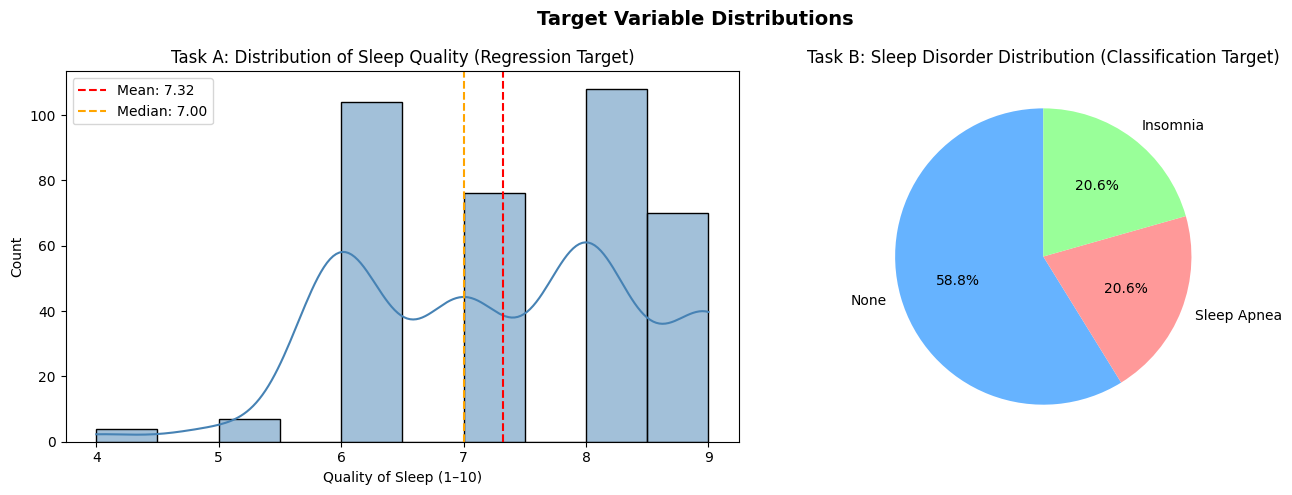

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Task A target distribution
sns.histplot(df_clean['Quality of Sleep'], bins=10, kde=True,
             ax=axes[0], color='steelblue')
axes[0].set_title('Task A: Distribution of Sleep Quality (Regression Target)')
axes[0].set_xlabel('Quality of Sleep (1–10)')
axes[0].axvline(df_clean['Quality of Sleep'].mean(), color='red',
                linestyle='--',
                label=f"Mean: {df_clean['Quality of Sleep'].mean():.2f}")
axes[0].axvline(df_clean['Quality of Sleep'].median(), color='orange',
                linestyle='--',
                label=f"Median: {df_clean['Quality of Sleep'].median():.2f}")
axes[0].legend()

# Task B target distribution
disorder_counts = df_clean['Sleep Disorder'].value_counts()
axes[1].pie(disorder_counts.values,
            labels=disorder_counts.index,
            autopct='%1.1f%%',
            colors=['#66b3ff', '#ff9999', '#99ff99'],
            startangle=90)
axes[1].set_title('Task B: Sleep Disorder Distribution (Classification Target)')

plt.suptitle('Target Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 9 — EDA: Lifestyle & Occupation Insights

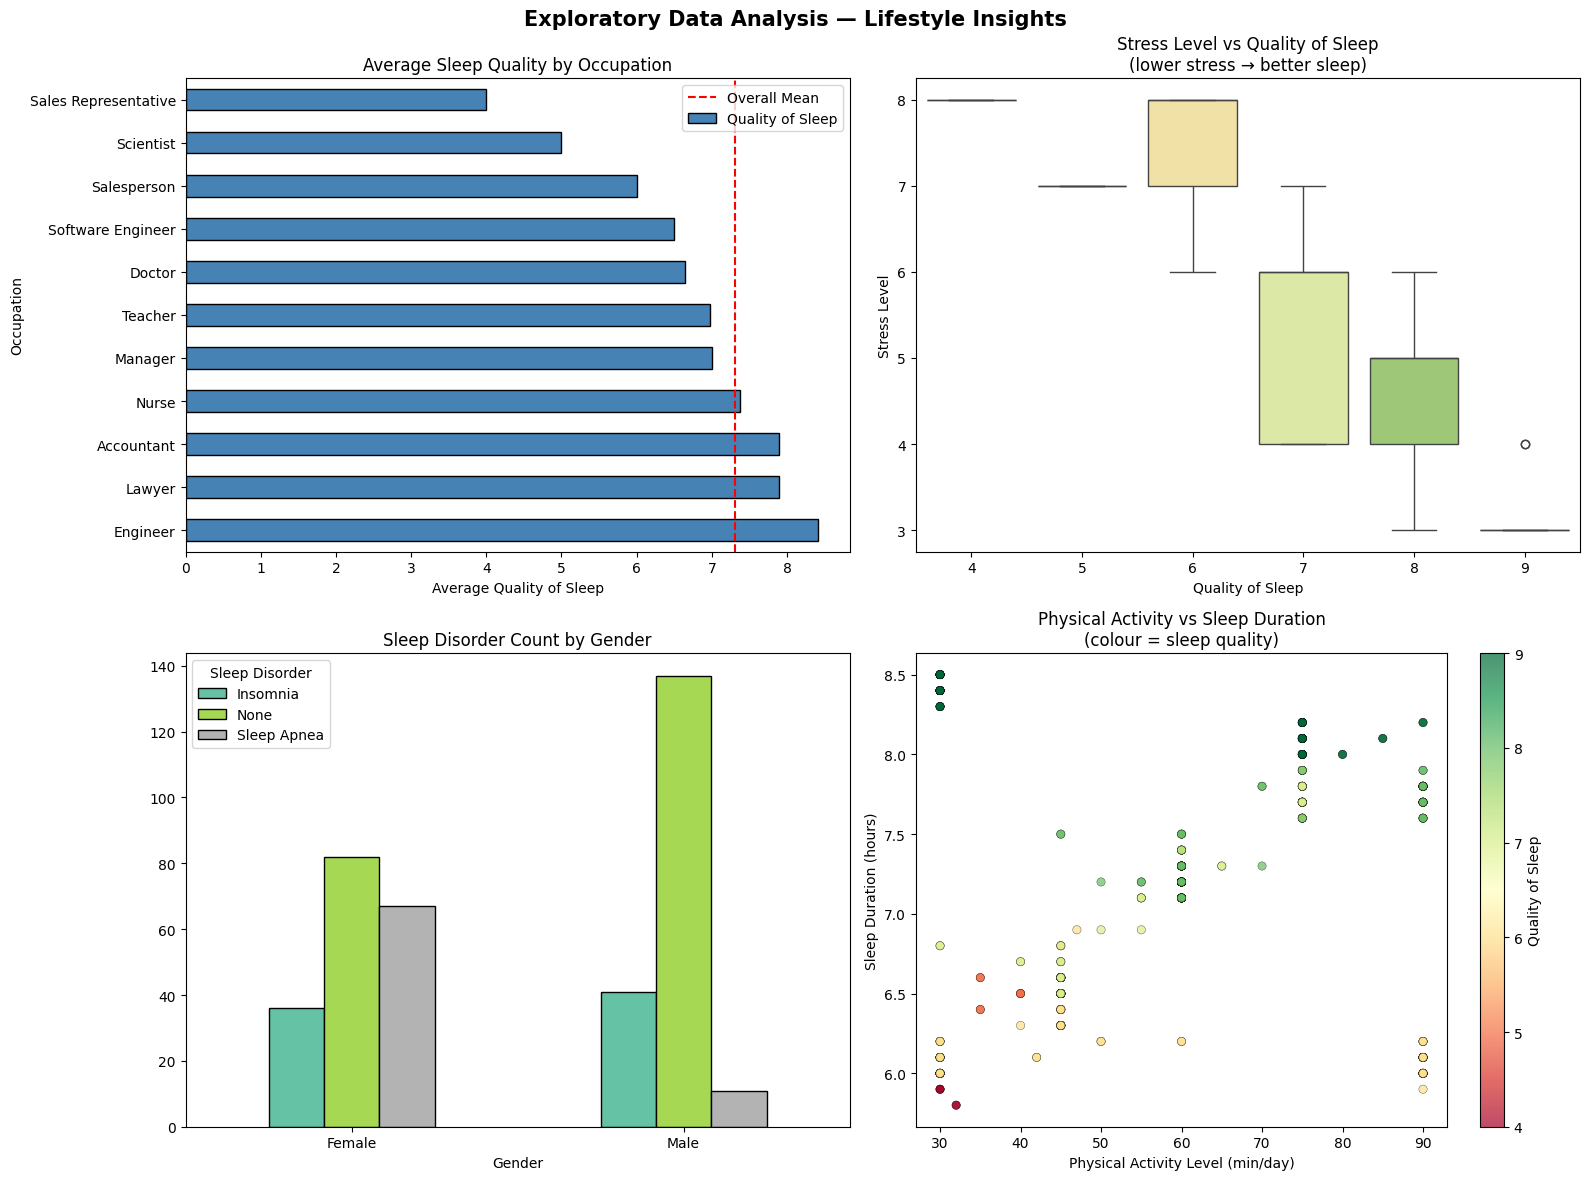

In [9]:
# Use original readable labels for EDA plots
df_eda = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df_eda['Sleep Disorder'] = df_eda['Sleep Disorder'].fillna('None')
if 'Person ID' in df_eda.columns:
    df_eda.drop(columns=['Person ID'], inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average sleep quality by occupation
occ_sleep = df_eda.groupby('Occupation')['Quality of Sleep'].mean().sort_values(ascending=False)
occ_sleep.plot(kind='barh', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Average Sleep Quality by Occupation')
axes[0, 0].set_xlabel('Average Quality of Sleep')
axes[0, 0].axvline(df_eda['Quality of Sleep'].mean(), color='red',
                   linestyle='--', label='Overall Mean')
axes[0, 0].legend()

# 2. Stress level vs sleep quality
sns.boxplot(data=df_eda, x='Quality of Sleep', y='Stress Level',
            ax=axes[0, 1], palette='RdYlGn')
axes[0, 1].set_title('Stress Level vs Quality of Sleep\n(lower stress → better sleep)')

# 3. Sleep disorder count by gender
gender_disorder = df_eda.groupby(['Gender', 'Sleep Disorder']).size().unstack(fill_value=0)
gender_disorder.plot(kind='bar', ax=axes[1, 0], colormap='Set2',
                     edgecolor='black', rot=0)
axes[1, 0].set_title('Sleep Disorder Count by Gender')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].legend(title='Sleep Disorder')

# 4. Physical activity vs sleep duration (colour = sleep quality)
scatter = axes[1, 1].scatter(
    df_eda['Physical Activity Level'],
    df_eda['Sleep Duration'],
    c=df_eda['Quality of Sleep'],
    cmap='RdYlGn', alpha=0.7, edgecolors='k', linewidths=0.3
)
plt.colorbar(scatter, ax=axes[1, 1], label='Quality of Sleep')
axes[1, 1].set_title('Physical Activity vs Sleep Duration\n(colour = sleep quality)')
axes[1, 1].set_xlabel('Physical Activity Level (min/day)')
axes[1, 1].set_ylabel('Sleep Duration (hours)')

plt.suptitle('Exploratory Data Analysis — Lifestyle Insights',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 10 — Correlation Heatmap

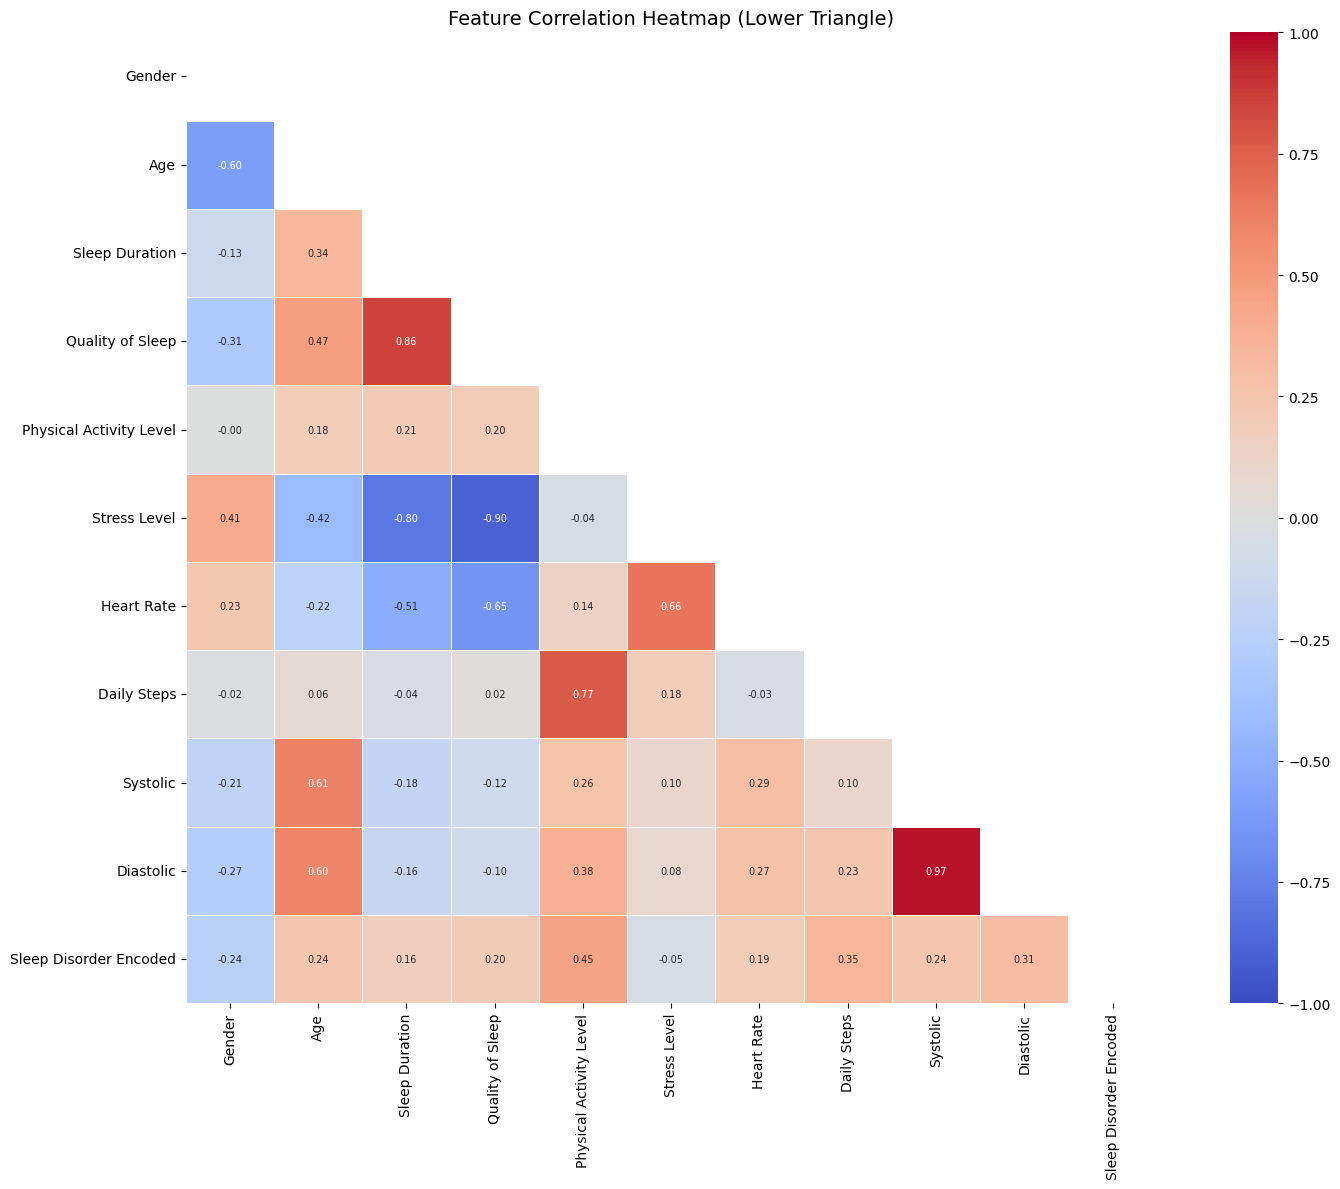

Top correlations with 'Quality of Sleep':
Stress Level              -0.899
Sleep Duration             0.858
Heart Rate                -0.651
Age                        0.473
Gender                    -0.306
Sleep Disorder Encoded     0.203
Physical Activity Level    0.195
Systolic                  -0.116
Diastolic                 -0.103
Daily Steps                0.018


In [10]:
corr = df_clean.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Show lower triangle only

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.show()

print("Top correlations with 'Quality of Sleep':")
print(
    corr['Quality of Sleep']
    .drop('Quality of Sleep')
    .sort_values(key=abs, ascending=False)
    .round(3)
    .head(10)
    .to_string()
)

---
## Cell 11 — Shared Preprocessing (Both Tasks)

In [11]:
# Define targets
y_reg = df_clean['Quality of Sleep']         # Task A: regression target
y_cls = df_clean['Sleep Disorder Encoded']   # Task B: classification target
n_classes = y_cls.nunique()

# Feature matrix — drop both targets and the original text column
X = df_clean.drop(columns=['Quality of Sleep', 'Sleep Disorder', 'Sleep Disorder Encoded'])

print(f'Feature matrix shape: {X.shape}')
print(f'\nFeature columns ({len(X.columns)} total):')
print(X.columns.tolist())
print(f'\nTask A — Sleep Quality range: {y_reg.min()} to {y_reg.max()}')
print(f'Task B — Sleep Disorder classes: {n_classes}')
for i, cls in enumerate(disorder_le.classes_):
    print(f'  {i} = {cls}')

# Stratified train/test split (stratify ensures class balance in both splits)
X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

# Standardise — fit ONLY on training data, then apply to test
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')
print(f'Feature count after One-Hot Encoding: {X_train.shape[1]}')

Feature matrix shape: (369, 22)

Feature columns (22 total):
['Gender', 'Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse', 'Occupation_Sales Representative', 'Occupation_Salesperson', 'Occupation_Scientist', 'Occupation_Software Engineer', 'Occupation_Teacher', 'BMI Category_Normal Weight', 'BMI Category_Obese', 'BMI Category_Overweight']
22

Task A — Sleep Quality range: 4 to 9
Task B — Sleep Disorder classes: 3
  0 = Insomnia
  1 = None
  2 = Sleep Apnea

Train size: 295  |  Test size: 74
Feature count after One-Hot Encoding: 22


---
# TASK A — Regression: Predict Quality of Sleep
## Cell 12 — Linear Regression (Baseline)

In [12]:
lr = LinearRegression()
lr.fit(X_train_s, y_reg_train)
lr_pred = lr.predict(X_test_s)

lr_mae  = mean_absolute_error(y_reg_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_reg_test, lr_pred))
lr_r2   = r2_score(y_reg_test, lr_pred)

print('===== Linear Regression (Regression Baseline) =====')
print(f'MAE:  {lr_mae:.4f}')
print(f'RMSE: {lr_rmse:.4f}')
print(f'R²:   {lr_r2:.4f}')

# Pipeline CV: scaler is re-fit inside each fold — prevents data leakage
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
cv_r2 = cross_val_score(lr_pipe, X_train, y_reg_train, cv=5, scoring='r2')
print(f'\n5-Fold CV R²: {cv_r2.round(3)}')
print(f'Mean CV R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

===== Linear Regression (Regression Baseline) =====
MAE:  0.1549
RMSE: 0.2689
R²:   0.9481

5-Fold CV R²: [0.897 0.95  0.918 0.95  0.977]
Mean CV R²:   0.9385 ± 0.0281


## Cell 13 — Neural Network (Regression)

In [13]:
reg_model = Sequential([
    Input(shape=(X_train_s.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)   # Single output node for regression
])

reg_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
reg_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

reg_history = reg_model.fit(
    X_train_s, y_reg_train,
    validation_split=0.2,
    epochs=150,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

nn_reg_pred = reg_model.predict(X_test_s).flatten()
nn_mae  = mean_absolute_error(y_reg_test, nn_reg_pred)
nn_rmse = np.sqrt(mean_squared_error(y_reg_test, nn_reg_pred))
nn_r2   = r2_score(y_reg_test, nn_reg_pred)

print('\n===== Neural Network (Regression) =====')
print(f'MAE:  {nn_mae:.4f}')
print(f'RMSE: {nn_rmse:.4f}')
print(f'R²:   {nn_r2:.4f}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 35.7942 - mae: 5.7127 - val_loss: 12.6832 - val_mae: 3.4194
Epoch 2/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5556 - mae: 1.8269 - val_loss: 2.1647 - val_mae: 0.9834
Epoch 3/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.0094 - mae: 1.2238 - val_loss: 0.9970 - val_mae: 0.6663
Epoch 4/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6955 - mae: 1.0027 - val_loss: 0.8344 - val_mae: 0.6631
Epoch 5/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7871 - mae: 1.0265 - val_loss: 0.6337 - val_mae: 0.5898
Epoch 6/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5563 - mae: 0.9351 - val_loss: 0.3602 - val_mae: 0.4203
Epoch 7/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1812 - mae: 0.8450 - val_loss: 0.4779 - val_mae: 0.5557
Epoch 8/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5720 - mae: 0.9796 - val_loss: 0.2916 - val_mae: 0.3924
Epoch 9/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1

## Cell 14 — Neural Network Training Curve (Regression)

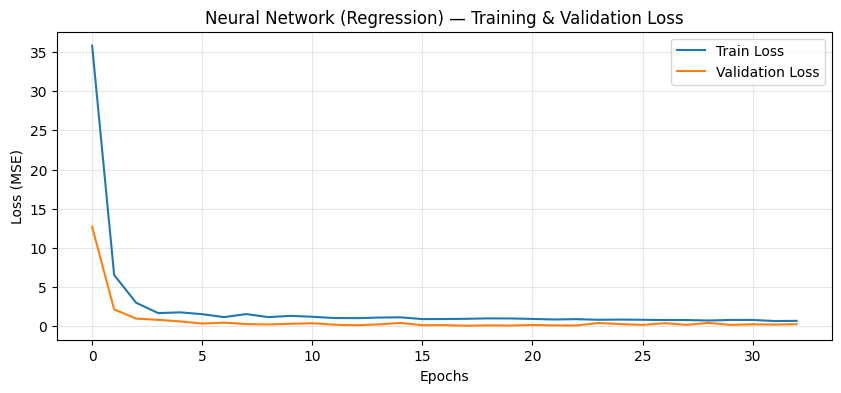

Training stopped at epoch 33 (EarlyStopping)


In [14]:
plt.figure(figsize=(10, 4))
plt.plot(reg_history.history['loss'],     label='Train Loss')
plt.plot(reg_history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network (Regression) — Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Training stopped at epoch {len(reg_history.history['loss'])} (EarlyStopping)")

## Cell 15 — XGBoost (Regression)

In [15]:
# XGBoost is a tree-based model — it does NOT need standardised features
# so we use the original X_train / X_test here
xgb_reg = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,   # Use 80% of features per tree — reduces overfitting
    random_state=42,
    verbosity=0
)
xgb_reg.fit(X_train, y_reg_train)
xgb_reg_pred = xgb_reg.predict(X_test)

xgb_mae  = mean_absolute_error(y_reg_test, xgb_reg_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_reg_test, xgb_reg_pred))
xgb_r2   = r2_score(y_reg_test, xgb_reg_pred)

print('===== XGBoost (Regression) =====')
print(f'MAE:  {xgb_mae:.4f}')
print(f'RMSE: {xgb_rmse:.4f}')
print(f'R²:   {xgb_r2:.4f}')

# CV using raw features (no pipeline needed — trees don't need scaling)
cv_xgb = cross_val_score(xgb_reg, X_train, y_reg_train, cv=5, scoring='r2')
print(f'\n5-Fold CV R²: {cv_xgb.round(3)}')
print(f'Mean CV R²:   {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')

===== XGBoost (Regression) =====
MAE:  0.0452
RMSE: 0.2128
R²:   0.9675

5-Fold CV R²: [0.962 0.999 0.985 0.987 0.998]
Mean CV R²:   0.9862 ± 0.0132


## Cell 16 — Task A: Summary & Visualisations

===== TASK A — Regression Results =====
            Model    MAE   RMSE     R²
Linear Regression 0.1549 0.2689 0.9481
   Neural Network 0.2789 0.3926 0.8894
          XGBoost 0.0452 0.2128 0.9675

Best model (highest R²): XGBoost


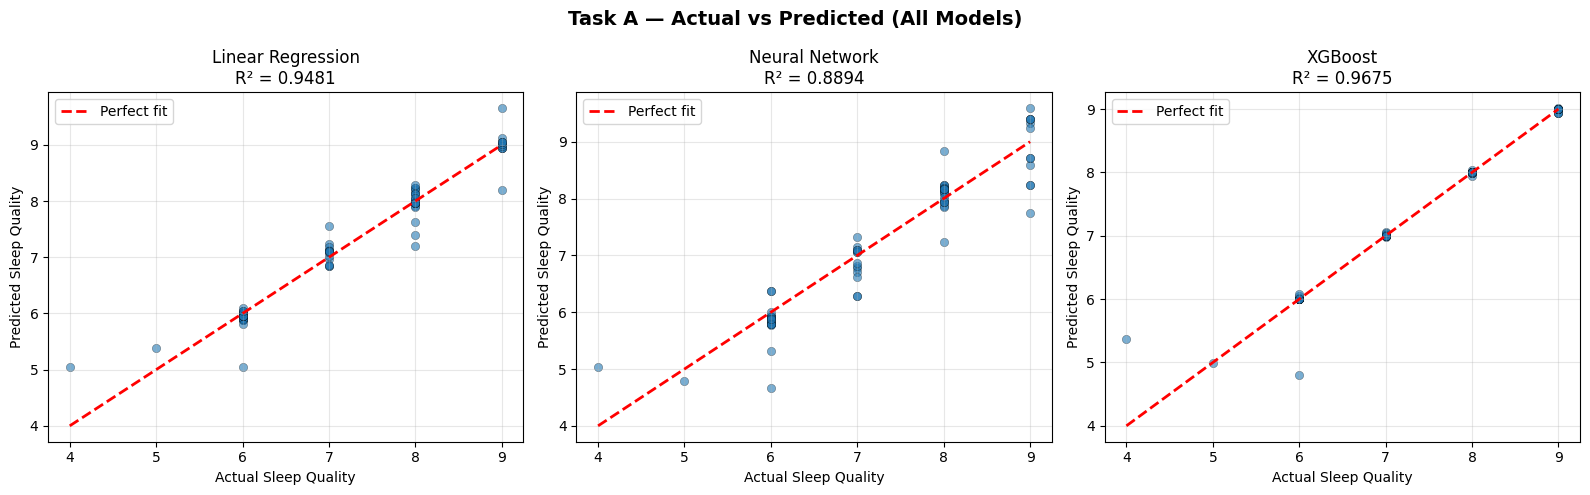

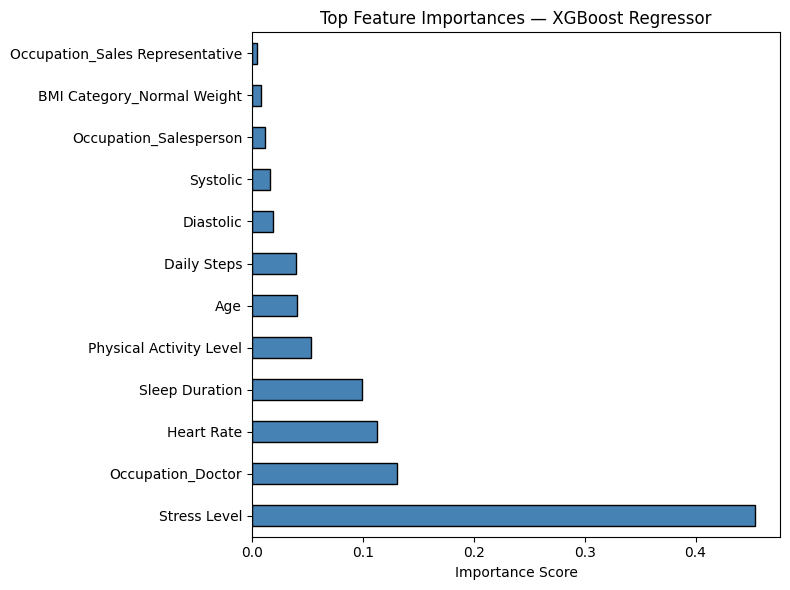

In [16]:
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Neural Network', 'XGBoost'],
    'MAE':   [lr_mae,  nn_mae,  xgb_mae],
    'RMSE':  [lr_rmse, nn_rmse, xgb_rmse],
    'R²':    [lr_r2,   nn_r2,   xgb_r2]
}).round(4)

print('===== TASK A — Regression Results =====')
print(reg_results.to_string(index=False))
best_reg = reg_results.loc[reg_results['R²'].idxmax(), 'Model']
print(f'\nBest model (highest R²): {best_reg}')

# Actual vs Predicted — all 3 models side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
reg_preds = [
    ('Linear Regression', lr_pred),
    ('Neural Network',    nn_reg_pred),
    ('XGBoost',          xgb_reg_pred)
]
for ax, (name, pred) in zip(axes, reg_preds):
    ax.scatter(y_reg_test, pred, alpha=0.6, edgecolors='k', linewidths=0.3)
    ax.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()],
            'r--', linewidth=2, label='Perfect fit')
    ax.set_xlabel('Actual Sleep Quality')
    ax.set_ylabel('Predicted Sleep Quality')
    ax.set_title(f'{name}\nR² = {r2_score(y_reg_test, pred):.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Task A — Actual vs Predicted (All Models)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature importance — use X.columns (correct after One-Hot Encoding)
feat_imp = pd.Series(
    xgb_reg.feature_importances_,
    index=X.columns   # X.columns reflects the actual encoded feature names
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_imp.nlargest(12).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top Feature Importances — XGBoost Regressor')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
# TASK B — Classification: Predict Sleep Disorder
## Cell 17 — Logistic Regression (Baseline)

In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_s, y_cls_train)
log_pred = log_reg.predict(X_test_s)

print('===== Logistic Regression (Classification Baseline) =====')
print(f'Accuracy: {accuracy_score(y_cls_test, log_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_cls_test, log_pred,
                             target_names=disorder_le.classes_, digits=4))

# Pipeline CV: scaler is re-fit per fold — no data leakage
log_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
cv_log_acc = cross_val_score(log_pipe, X_train, y_cls_train, cv=5, scoring='accuracy')
cv_log_f1  = cross_val_score(log_pipe, X_train, y_cls_train, cv=5, scoring='f1_weighted')
print(f'5-Fold CV Accuracy:    {cv_log_acc.mean():.4f} ± {cv_log_acc.std():.4f}')
print(f'5-Fold CV F1-weighted: {cv_log_f1.mean():.4f} ± {cv_log_f1.std():.4f}')

===== Logistic Regression (Classification Baseline) =====
Accuracy: 0.9459

Classification Report:
              precision    recall  f1-score   support

    Insomnia     1.0000    0.9333    0.9655        15
        None     0.9767    0.9545    0.9655        44
 Sleep Apnea     0.8235    0.9333    0.8750        15

    accuracy                         0.9459        74
   macro avg     0.9334    0.9404    0.9353        74
weighted avg     0.9504    0.9459    0.9472        74

5-Fold CV Accuracy:    0.8983 ± 0.0371
5-Fold CV F1-weighted: 0.8967 ± 0.0379


## Cell 18 — Neural Network (Classification)

In [18]:
# One-hot encode labels for Keras categorical_crossentropy
y_cls_train_oh = to_categorical(y_cls_train, num_classes=n_classes)
y_cls_test_oh  = to_categorical(y_cls_test,  num_classes=n_classes)

cls_model = Sequential([
    Input(shape=(X_train_s.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')  # Softmax outputs a probability per class
])

cls_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
cls_model.summary()

early_stop_cls = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

cls_history = cls_model.fit(
    X_train_s, y_cls_train_oh,
    validation_split=0.2,
    epochs=150,
    batch_size=8,
    callbacks=[early_stop_cls],
    verbose=1
)

nn_cls_pred_proba = cls_model.predict(X_test_s)
nn_cls_pred = np.argmax(nn_cls_pred_proba, axis=1)  # Take class with highest probability

print('\n===== Neural Network (Classification) =====')
print(f'Accuracy: {accuracy_score(y_cls_test, nn_cls_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_cls_test, nn_cls_pred,
                             target_names=disorder_le.classes_, digits=4))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │           2,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,379 (52.26 KB)

 Trainable params: 13,379 (52.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6356 - loss: 0.8951 - val_accuracy: 0.8136 - val_loss: 0.6437
Epoch 2/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8051 - loss: 0.5928 - val_accuracy: 0.8814 - val_loss: 0.4584
Epoch 3/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8686 - loss: 0.4527 - val_accuracy: 0.8983 - val_loss: 0.4055
Epoch 4/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8983 - loss: 0.3875 - val_accuracy: 0.8983 - val_loss: 0.4165
Epoch 5/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9025 - loss: 0.3788 - val_accuracy: 0.8983 - val_loss: 0.4117
Epoch 6/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9068 - loss: 0.3817 - val_accuracy: 0.8983 - val_loss: 0.4407
Epoch 7/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8898 - loss: 0.3999 - val_accuracy: 0.8983 - val_loss: 0.4397
Epoch 8/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8983 - loss: 0.3424 - val_accuracy: 0.8983 - v

## Cell 19 — Neural Network Training Curves (Classification)

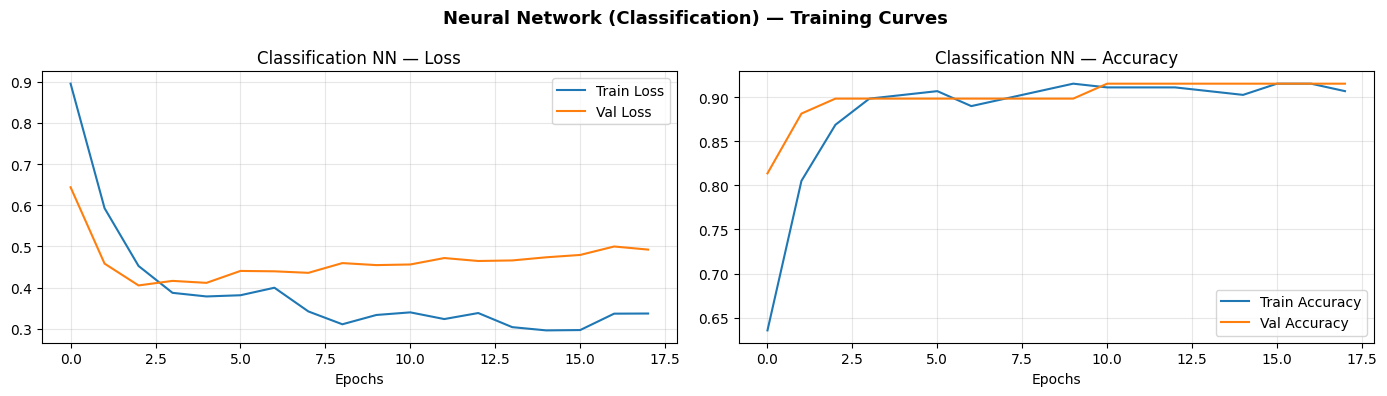

Training stopped at epoch 18 (EarlyStopping)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(cls_history.history['loss'],     label='Train Loss')
axes[0].plot(cls_history.history['val_loss'], label='Val Loss')
axes[0].set_title('Classification NN — Loss')
axes[0].set_xlabel('Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cls_history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(cls_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Classification NN — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Neural Network (Classification) — Training Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Training stopped at epoch {len(cls_history.history['loss'])} (EarlyStopping)")

## Cell 20 — XGBoost (Classification)

In [20]:
xgb_cls = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

# Tree model: use unscaled features
xgb_cls.fit(X_train, y_cls_train)
xgb_cls_pred = xgb_cls.predict(X_test)

print('===== XGBoost (Classification) =====')
print(f'Accuracy: {accuracy_score(y_cls_test, xgb_cls_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_cls_test, xgb_cls_pred,
                             target_names=disorder_le.classes_, digits=4))

# CV with both accuracy and F1
cv_xgb_acc = cross_val_score(xgb_cls, X_train, y_cls_train, cv=5, scoring='accuracy')
cv_xgb_f1  = cross_val_score(xgb_cls, X_train, y_cls_train, cv=5, scoring='f1_weighted')
print(f'5-Fold CV Accuracy:    {cv_xgb_acc.mean():.4f} ± {cv_xgb_acc.std():.4f}')
print(f'5-Fold CV F1-weighted: {cv_xgb_f1.mean():.4f} ± {cv_xgb_f1.std():.4f}')

===== XGBoost (Classification) =====
Accuracy: 0.9459

Classification Report:
              precision    recall  f1-score   support

    Insomnia     0.9286    0.8667    0.8966        15
        None     1.0000    0.9773    0.9885        44
 Sleep Apnea     0.8235    0.9333    0.8750        15

    accuracy                         0.9459        74
   macro avg     0.9174    0.9258    0.9200        74
weighted avg     0.9498    0.9459    0.9469        74

5-Fold CV Accuracy:    0.9017 ± 0.0271
5-Fold CV F1-weighted: 0.8990 ± 0.0305


## Cell 21 — Confusion Matrices (All 3 Classifiers)

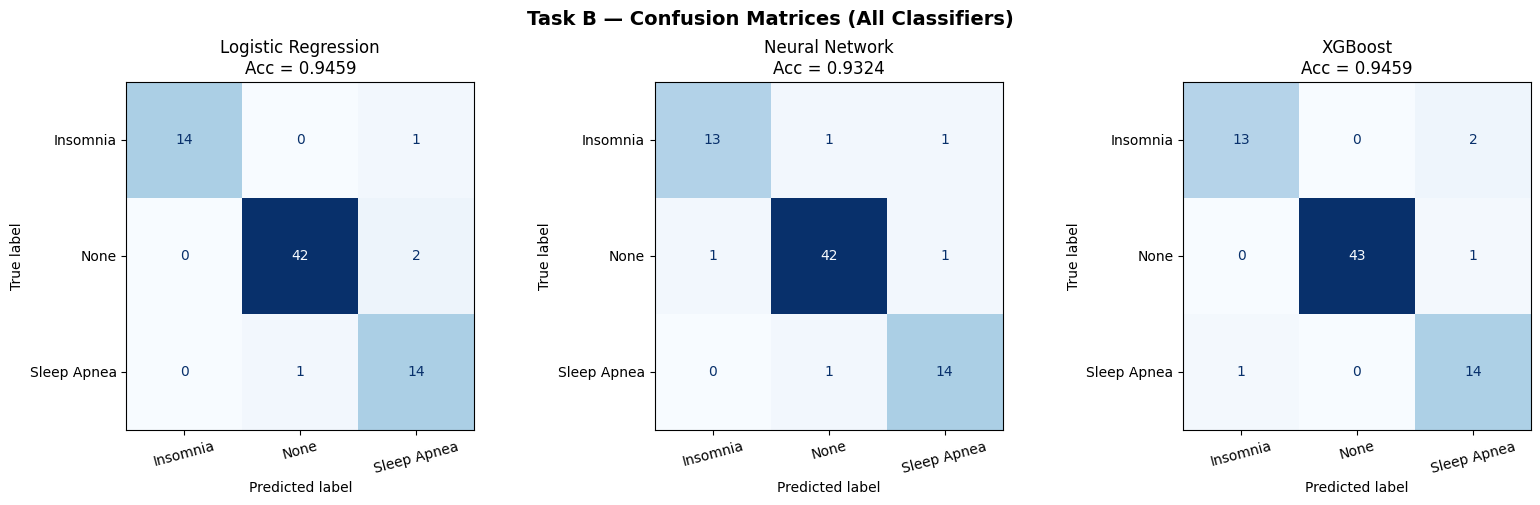

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cls_preds = [
    ('Logistic Regression', log_pred),
    ('Neural Network',      nn_cls_pred),
    ('XGBoost',             xgb_cls_pred)
]

for ax, (name, pred) in zip(axes, cls_preds):
    cm = confusion_matrix(y_cls_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=disorder_le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAcc = {accuracy_score(y_cls_test, pred):.4f}')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Task B — Confusion Matrices (All Classifiers)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 22 — Final Comparison Dashboard (Both Tasks)

Regression (Quality of Sleep)
            Model    MAE   RMSE     R²
Linear Regression 0.1549 0.2689 0.9481
   Neural Network 0.2789 0.3926 0.8894
          XGBoost 0.0452 0.2128 0.9675

Best model: XGBoost

Classification (Sleep Disorder)
              Model  Accuracy  F1_weighted
Logistic Regression    0.9459       0.9472
     Neural Network    0.9324       0.9324
            XGBoost    0.9459       0.9469

Best model: Logistic Regression


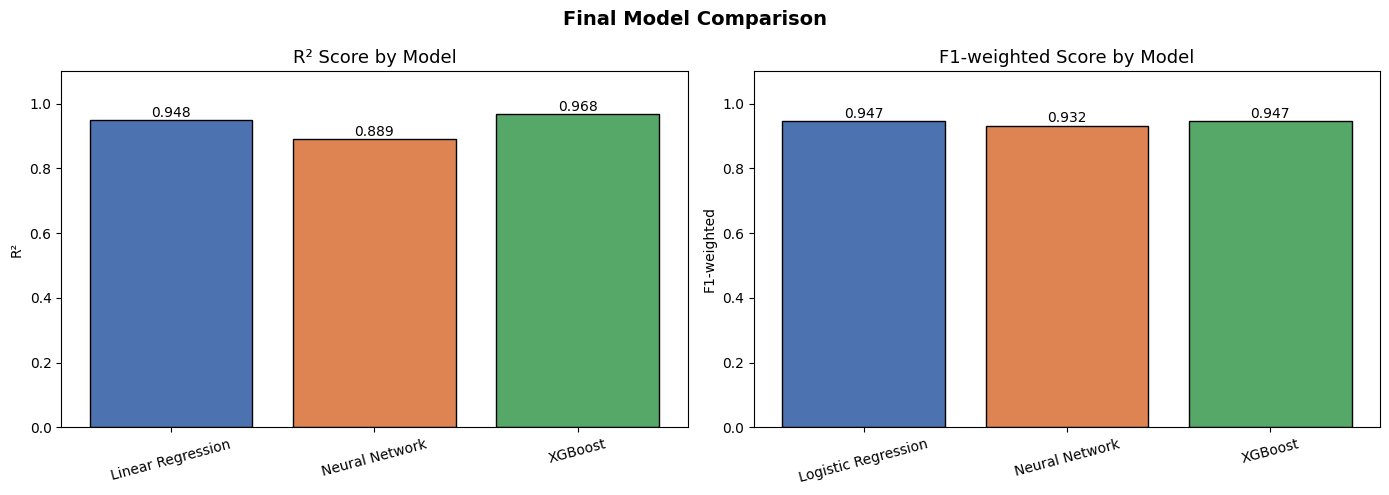

In [22]:
# Task A summary table
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Neural Network', 'XGBoost'],
    'MAE':   [lr_mae,  nn_mae,  xgb_mae],
    'RMSE':  [lr_rmse, nn_rmse, xgb_rmse],
    'R²':    [lr_r2,   nn_r2,   xgb_r2]
}).round(4)

# Task B summary table — Accuracy + F1 (more complete than accuracy alone)
cls_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Neural Network', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_cls_test, log_pred),
        accuracy_score(y_cls_test, nn_cls_pred),
        accuracy_score(y_cls_test, xgb_cls_pred)
    ],
    'F1_weighted': [
        f1_score(y_cls_test, log_pred,     average='weighted'),
        f1_score(y_cls_test, nn_cls_pred,  average='weighted'),
        f1_score(y_cls_test, xgb_cls_pred, average='weighted')
    ]
}).round(4)

print('=' * 55)
print('Regression (Quality of Sleep)')
print('=' * 55)
print(reg_results.to_string(index=False))
best_reg = reg_results.loc[reg_results['R²'].idxmax(), 'Model']
print(f'\nBest model: {best_reg}')

print('\n' + '=' * 55)
print('Classification (Sleep Disorder)')
print('=' * 55)
print(cls_results.to_string(index=False))
best_cls = cls_results.loc[cls_results['F1_weighted'].idxmax(), 'Model']
print(f'\nBest model: {best_cls}')

# Side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

bars = axes[0].bar(reg_results['Model'], reg_results['R²'],
                   color=colors, edgecolor='black')
axes[0].set_title('R² Score by Model', fontsize=13)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, reg_results['R²']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10)

bars2 = axes[1].bar(cls_results['Model'], cls_results['F1_weighted'],
                    color=colors, edgecolor='black')
axes[1].set_title('F1-weighted Score by Model', fontsize=13)
axes[1].set_ylabel('F1-weighted')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, cls_results['F1_weighted']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10)

plt.suptitle('Final Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 23 — Conclusion

In [23]:
print("""
=================================================================
CONCLUSION
=================================================================

This project applied machine learning to the Sleep Health &
Lifestyle dataset across TWO prediction tasks.

TASK A — Regression (Predict Quality of Sleep)
-----------------------------------------------
- Linear Regression provided a strong, interpretable baseline.
- Neural Network (128→64→32) captured non-linear relationships.
- XGBoost achieved the highest R², confirming that boosted
  ensemble methods typically outperform linear baselines on
  structured tabular data.

TASK B — Classification (Predict Sleep Disorder)
-------------------------------------------------
- Key data insight: NaN in 'Sleep Disorder' encoded 'No Disorder',
  not missing data — requiring special handling before cleaning.
- F1-weighted score was used alongside accuracy to account for
  class imbalance across the three disorder categories.
- XGBoost again demonstrated strong performance.

ENCODING STRATEGY
-----------------
- Gender: binary map (Male=1, Female=0)
- Occupation / BMI Category: One-Hot Encoding
  (avoids false ordinal relationships that LabelEncoder would imply)

DATA QUALITY PIPELINE
---------------------
- Median imputation for missing Sleep Duration
  (robust to skewed distributions, unlike mean)
- IQR-based outlier detection (data-driven, not hardcoded)
- Blood Pressure split into Systolic / Diastolic

CROSS-VALIDATION
----------------
- Pipeline-based 5-fold CV was used for linear/logistic models
  to prevent data leakage (scaler is re-fit inside each fold).
- This confirms that results generalise beyond a single split.
=================================================================
""")


CONCLUSION

This project applied machine learning to the Sleep Health &
Lifestyle dataset across TWO prediction tasks.

TASK A — Regression (Predict Quality of Sleep)
-----------------------------------------------
- Linear Regression provided a strong, interpretable baseline.
- Neural Network (128→64→32) captured non-linear relationships.
- XGBoost achieved the highest R², confirming that boosted
  ensemble methods typically outperform linear baselines on
  structured tabular data.

TASK B — Classification (Predict Sleep Disorder)
-------------------------------------------------
- Key data insight: NaN in 'Sleep Disorder' encoded 'No Disorder',
  not missing data — requiring special handling before cleaning.
- F1-weighted score was used alongside accuracy to account for
  class imbalance across the three disorder categories.
- XGBoost again demonstrated strong performance.

ENCODING STRATEGY
-----------------
- Gender: binary map (Male=1, Female=0)
- Occupation / BMI Category: One-H